In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()
  
# variable information 
print(heart_disease.variables) 


        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2              

In [3]:
X.head()      

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [4]:
X.info()     
X.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [5]:
y.info()     
y.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   num     303 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB


,num
count,303.000000
mean,0.937294
std,1.228536
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,4.000000


## Identify categorical/binary features

In [6]:
y['num'].unique()

array([0, 2, 1, 3, 4])

In [7]:
X['ca'].unique()

array([ 0.,  3.,  2.,  1., nan])

In [8]:
X['thal'].unique()

array([ 6.,  3.,  7., nan])

In [9]:
X['slope'].unique()

array([3, 2, 1])

In [10]:
X['restecg'].unique()

array([2, 0, 1])

In [11]:
X['sex'].unique()

array([1, 0])

In [12]:
X['exang'].unique()

array([0, 1])

In [13]:
## Check number of missing rows
X[['ca', 'thal']].isnull().sum()

ca      4
thal    2
dtype: int64

## Drop Missing Rows:
Since there are only a few rows containing missing values, it is okay to drop them to avoid making assuptions in medical data.

In [14]:
X = X.dropna(subset=['ca', 'thal'])

In [15]:
X.head()      
X.info()     
X.describe() 

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 32.5 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


#### Num: diagnosis of heart disease
- numbered as 0, 1, 2, 3, or 4
- 0 = no heart disease
- 1 - 4 = has heart disease
    - 1 = mild
    - 2 = moderate
    - 3 = severe
    - 4 = very severe

For plotting, we will simplify this as:
- 0 = no heart disease
- 1 = heart disease present

In [16]:
## Combine features (X) and target (y)
df = X.copy()
df['num'] = y

In [17]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [18]:
## Change num to either 0 (disease negative) or 1 (disease positive)
df['num_binary'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [19]:
y = df['num_binary']
X = df.drop(columns=['num', 'num_binary'])

In [20]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'num_binary'],
      dtype='object')


In [21]:
## Color palette
palette = {0: "#568BCB", 1: "#9E1B1B"}

In [22]:
# Color palette for Heatmap
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "custom_red",
    ["#568BCB", "#FFE0E0", "#9E1B1B"]
)

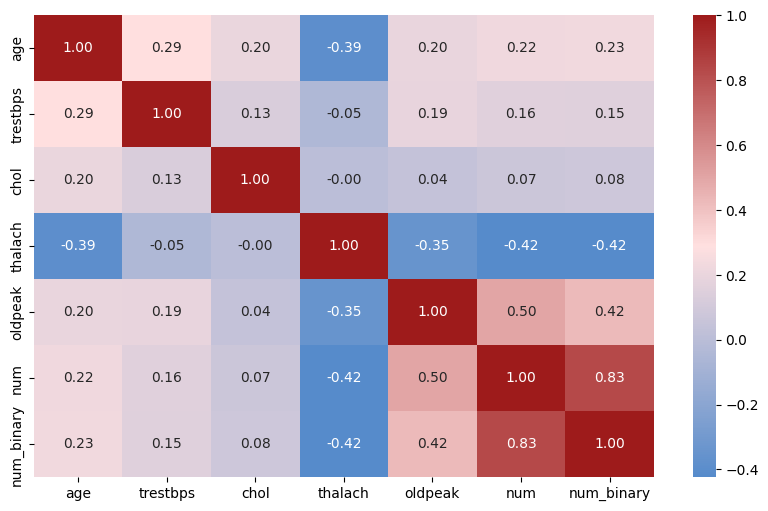

In [23]:
## Plot Heatmap with numerical features and target
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'num', 'num_binary']
corr = df[num_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap = cmap, fmt=".2f")
plt.show()

# Numerical Features with highest correlation with target:

### Strong features
- oldpeak (0.50): Difference in the ST segment level between rest and exercise (how well does the heart handle stress)

### Moderate features
- thalach (-0.42): Indicates max heart rate (lower the rate, higher the chance of having heart disease)

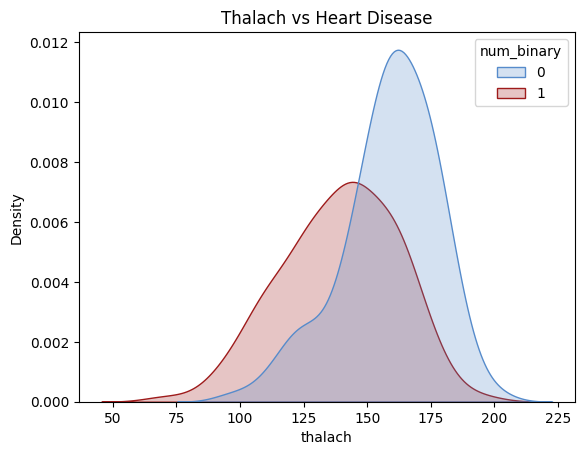

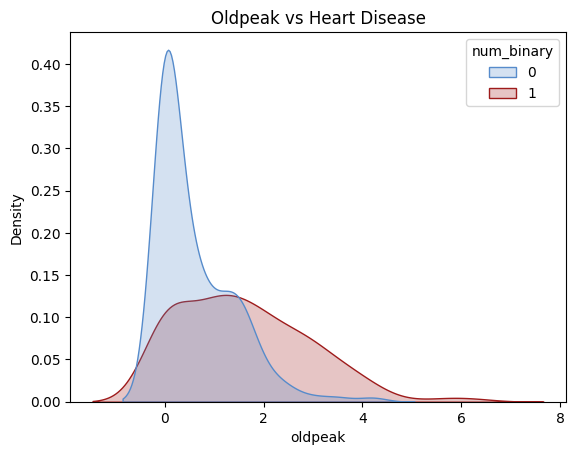

In [24]:
### Highest correlated features grouped by num_binary (continuous features)

# thalach & num
sns.kdeplot(data=df, x='thalach', hue='num_binary',palette=palette, fill=True)
plt.title("Thalach vs Heart Disease")
plt.show()

# oldpeak & num
sns.kdeplot(data=df, x='oldpeak', hue='num_binary', palette=palette, fill=True)
plt.title("Oldpeak vs Heart Disease")
plt.show()

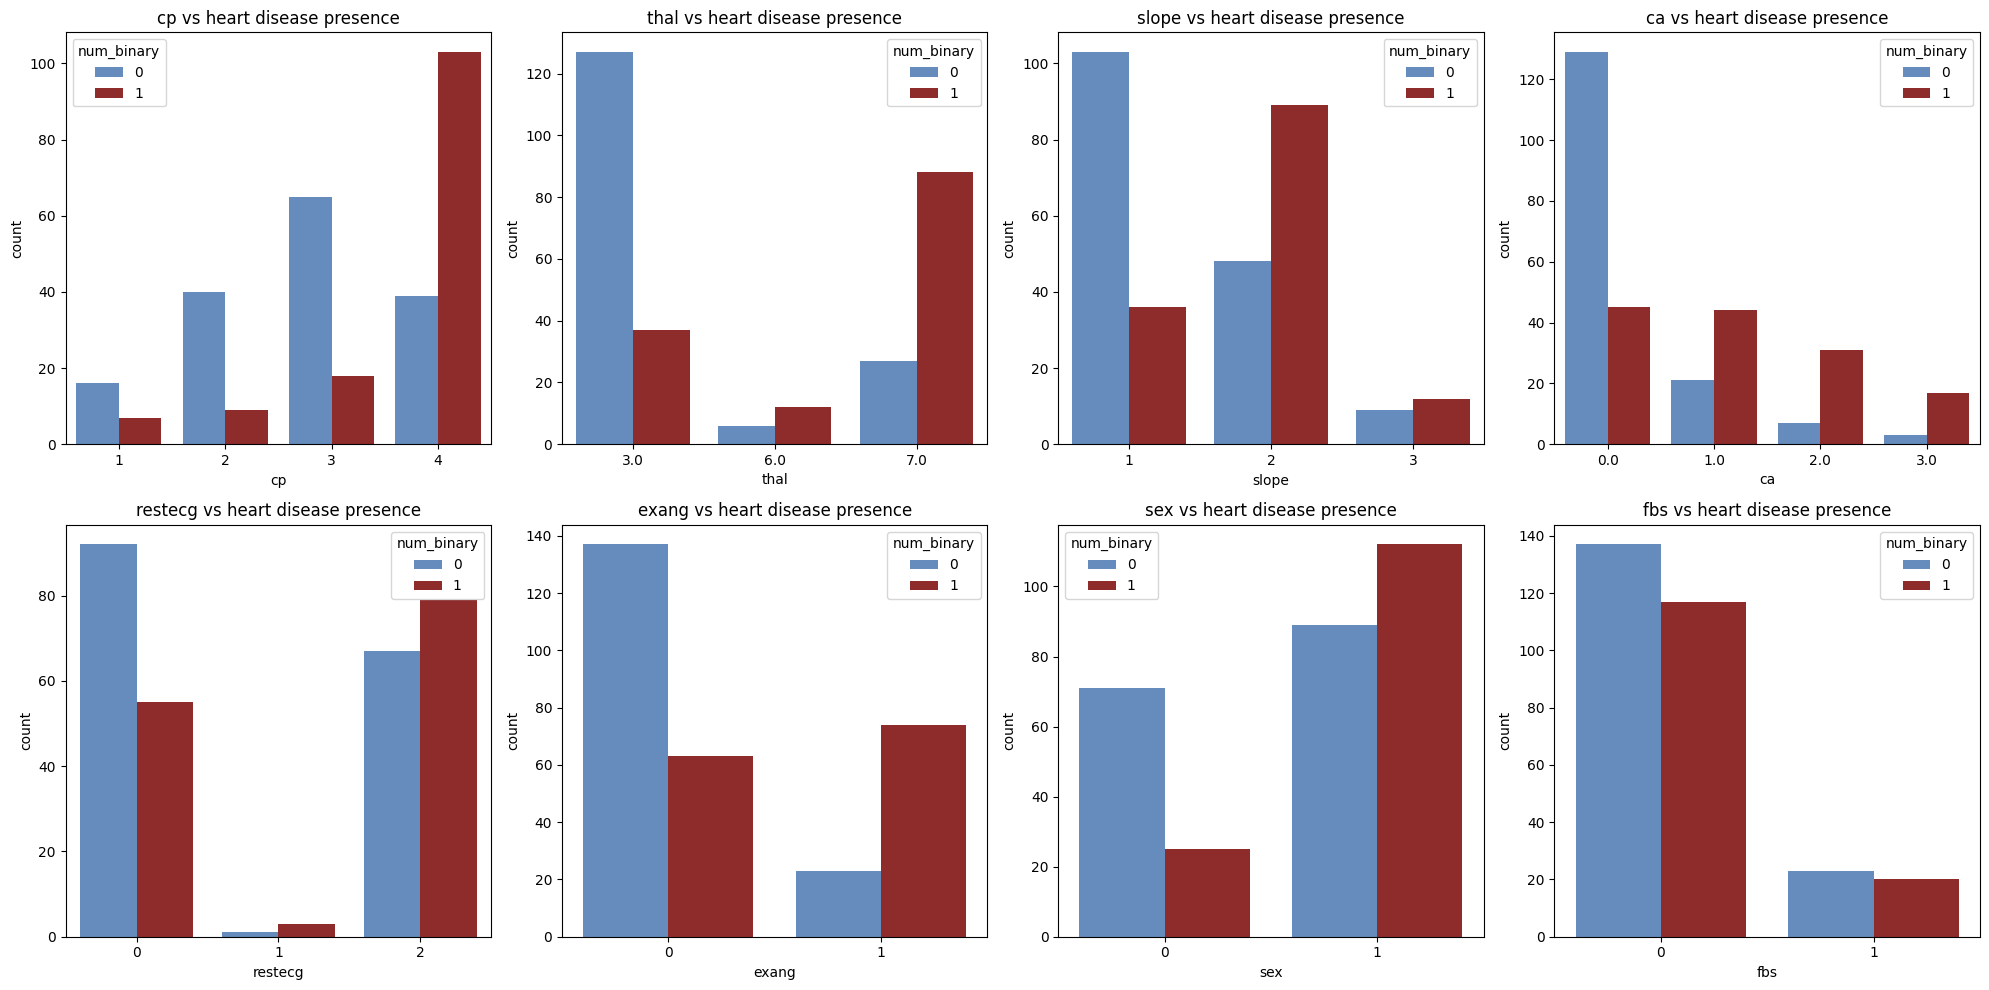

In [25]:
### Categorical features grouped by num_binary (discrete features)

categorical_features = ['cp','thal','slope','ca','restecg','exang','sex','fbs']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue='num_binary',palette=palette, ax=axes[i])
    axes[i].set_title(f"{col} vs heart disease presence")

plt.tight_layout()
plt.show()


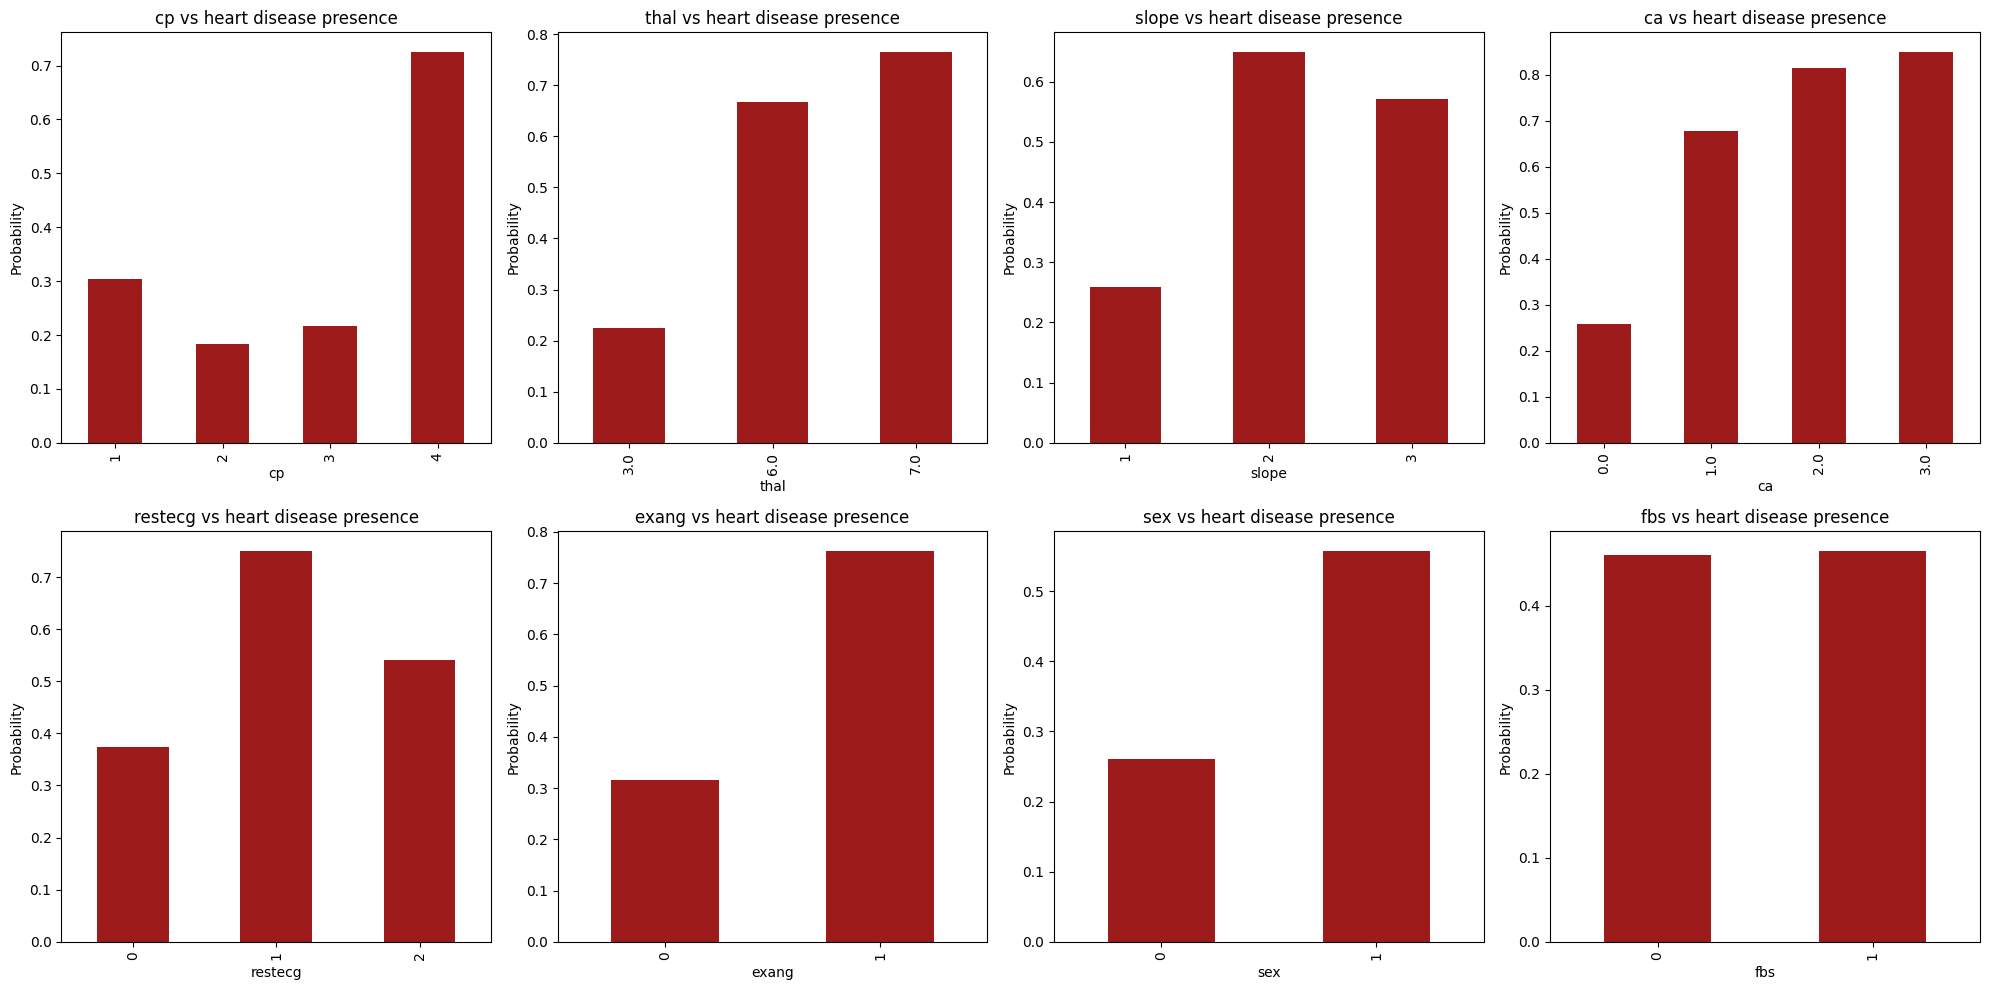

In [26]:
### Categorical features grouped by num_binary using probability (discrete features)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    
    probs = df.groupby(col)['num_binary'].mean()
    
    probs.plot(kind='bar', color = "#9E1B1B", ax=axes[i])
    axes[i].set_title(f"{col} vs heart disease presence")
    axes[i].set_ylabel("Probability")

plt.tight_layout()
plt.show()

In [27]:
## Difference in probability between presence and absence of heart disease
results = []

for col in categorical_features:
    probs = df.groupby(col)['num_binary'].mean()

    diff = probs.max() - probs.min()
    results.append((col, diff))

results_df = pd.DataFrame(results, columns=['feature', 'prob_diff'])
results_df = results_df.sort_values('prob_diff', ascending=False)
results_df

,feature,prob_diff
3,ca,0.591379
0,cp,0.541679
1,thal,0.539608
5,exang,0.447887
2,slope,0.390642
4,restecg,0.375850
6,sex,0.296797
7,fbs,0.004486


# Considerable Categorical Features from Probability Difference:
### Strong features
- ca (0.591): Indicates number of blocked blood vessels 
- cp (0.541): Chest pain type from 0-4
- thal (0.539): Measuring blood flow to the heart (3 = nomal, 6 = fixed defect, 7 = reversable defect)

### Moderate features
- exang (0.448): Exercise induced angina
- slope(0.391): ST slope during exercise ECG
- restecg (0.376): Resting ECG results